# Bankruptcy Prediction — Interpretation

This notebook explains the XGBoost model predictions using SHAP values.

**Goals:**
- Understand which features drive bankruptcy predictions globally (feature importance vs SHAP)
- Explain individual predictions — why did the model flag a specific company as bankrupt?
- Analyze model errors — which bankruptcies were missed and why?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

C:\Users\MikitaLutsik\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Reproduce Pipeline

We rebuild the full preprocessing pipeline from scratch to get
the trained model and processed data for interpretation.

In [3]:
df = pd.read_csv('data.csv')
df.columns = df.columns.str.strip()

columns_to_drop = [
    'ROA(A) before interest and % after tax',
    'ROA(B) before interest and depreciation after tax',
    'ROA(C) before interest and depreciation before interest',
    'Net Value Per Share (B)', 'Net Value Per Share (C)',
    'Debt ratio %', 'Current Liabilities/Equity',
    'Current Liability to Equity', 'Current Liabilities/Liability',
    'Current Liability to Liability', 'Borrowing dependency',
    'Net profit before tax/Paid-in capital',
    'Per Share Net profit before tax (Yuan \u00c2\u00a5)',
    'Operating Gross Margin', 'Realized Sales Gross Margin',
    'Continuous interest rate (after tax)', 'Pre-tax net Interest Rate',
    'After-tax net Interest Rate', 'Working capitcal Turnover Rate',
    'Net Income Flag',
]
df = df.drop(columns=columns_to_drop)

X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clip_bounds = {}
X_train_clipped = X_train.copy()
X_test_clipped  = X_test.copy()

for col in X_train.columns:
    lo = X_train[col].quantile(0.01)
    hi = X_train[col].quantile(0.99)
    clip_bounds[col] = (lo, hi)
    X_train_clipped[col] = X_train[col].clip(lo, hi)
    X_test_clipped[col]  = X_test[col].clip(lo, hi)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    random_state=42,
    eval_metric='aucpr'
)
xgb.fit(X_train_clipped, y_train)

print('Pipeline reproduced successfully')
print(f'X_train: {X_train_clipped.shape}, X_test: {X_test_clipped.shape}')

Pipeline reproduced successfully
X_train: (5455, 75), X_test: (1364, 75)


## 2. SHAP Values

SHAP (SHapley Additive exPlanations) explains why the model made
a specific prediction for each company.

Unlike feature importance (which shows global averages), SHAP shows
the exact contribution of each feature for every individual prediction.

In [4]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_clipped)

print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (1364, 75)


## 3. Global Feature Importance (SHAP)

SHAP summary plot shows the most influential features across all companies
in the test set. Each dot represents one company.

**How to read:**
- X axis: SHAP value — impact on model prediction
  - Positive (right) → pushes toward bankruptcy
  - Negative (left) → pushes toward health
- Color: feature value (red = high, blue = low)

**Key findings:**
- Low Retained Earnings to Total Assets is the strongest bankruptcy signal —
  companies without accumulated reserves are highly vulnerable
- High Total debt/Total net worth pushes strongly toward bankruptcy —
  overleveraged companies are at risk
- Persistent EPS works both ways — very

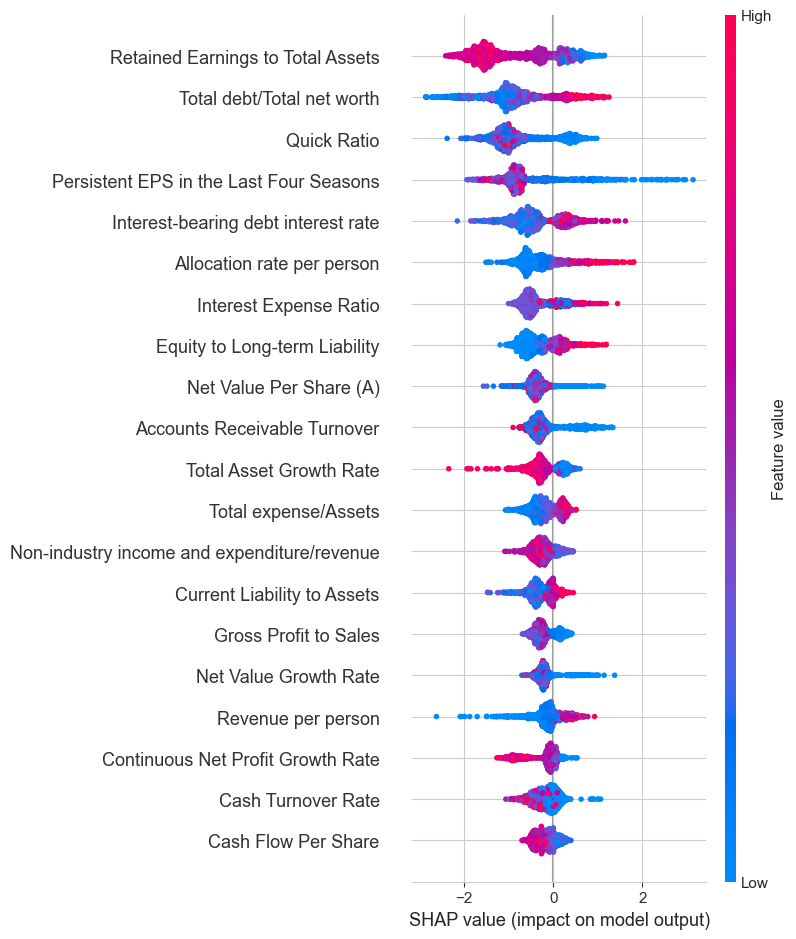

In [5]:
shap.summary_plot(shap_values, X_test_clipped, max_display=20)

## 4. Individual Prediction Explanation (Waterfall Plot)

Waterfall plot for one bankrupt company from the test set.

E[f(x)] = -0.175 — model's baseline prediction (average across all companies)
f(x) = 1.228 — final prediction for this company (positive = bankrupt)

Red bars push toward bankruptcy, blue bars push toward health.

Key drivers for this company:
- Persistent EPS = 0.197 — very low earnings per share (+1.32)
- Quick Ratio = 0.002 — near-zero liquidity (+0.77)
- These two signals alone were enough to flag this company as bankrupt

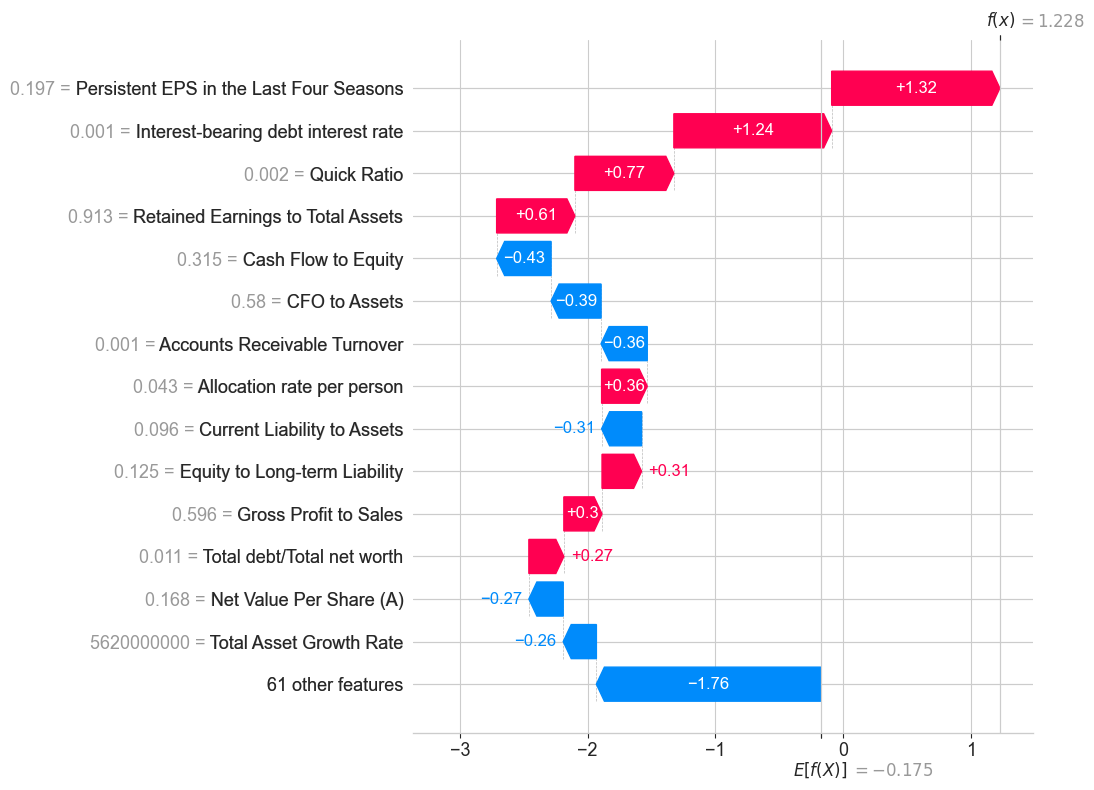

In [6]:
# take 1st bankrupt company
bankrupt_idx = y_test[y_test == 1].index[0]
sample_pos = X_test_clipped.index.get_loc(bankrupt_idx)

explanation = shap.Explanation(
    values=shap_values[sample_pos],
    base_values=explainer.expected_value,
    data=X_test_clipped.iloc[sample_pos],
    feature_names=X_test_clipped.columns.tolist()
)

shap.plots.waterfall(explanation, max_display=15)

## 5. Error Analysis — Missed Bankruptcies (False Negatives)

These are real bankrupt companies that the model failed to catch.
Understanding why helps identify the model's blind spots.

We use threshold = 0.20 (our tuned threshold from notebook 02).

In [8]:
y_proba_xgb = xgb.predict_proba(X_test_clipped)[:, 1]
y_pred_tuned = (y_proba_xgb >= 0.20).astype(int)

In [10]:
fn_mask = (y_test == 1) & (y_pred_tuned == 0)
fn_companies = X_test_clipped[fn_mask].copy()
fn_companies['predicted_proba'] = y_proba_xgb[fn_mask]

print(f'Missed bankruptcies: {fn_mask.sum()} out of {y_test.sum()} real bankruptcies')
print(f'\nPredicted probabilities for missed companies:')
print(fn_companies['predicted_proba'].sort_values(ascending=False).round(3).to_string())

Missed bankruptcies: 14 out of 44 real bankruptcies

Predicted probabilities for missed companies:
1870    0.162
2095    0.117
5313    0.106
1754    0.067
1953    0.015
379     0.011
1446    0.007
2704    0.004
233     0.002
948     0.002
2392    0.002
4375    0.001
4491    0.000
2003    0.000


In [14]:
# Compare missed bankruptcies with average values for healthy companies
top_features = ['Retained Earnings to Total Assets',
                'Persistent EPS in the Last Four Seasons',
                'Total debt/Total net worth',
                'Quick Ratio',
                'Interest Expense Ratio']

healthy_mean = X_test_clipped[y_test == 0][top_features].mean()
missed_mean  = fn_companies[top_features].mean()

comparison = pd.DataFrame({
    'Healthy (mean)': healthy_mean.round(3),
    'Missed Bankrupts (mean)': missed_mean.round(3)
})
print(comparison)

                                         Healthy (mean)  \
Retained Earnings to Total Assets                 0.937   
Persistent EPS in the Last Four Seasons           0.231   
Total debt/Total net worth                        0.007   
Quick Ratio                                       0.011   
Interest Expense Ratio                            0.631   

                                         Missed Bankrupts (mean)  
Retained Earnings to Total Assets                          0.914  
Persistent EPS in the Last Four Seasons                    0.204  
Total debt/Total net worth                                 0.015  
Quick Ratio                                                0.005  
Interest Expense Ratio                                     0.631  


## 6. Conclusions

### What SHAP revealed

SHAP analysis confirmed and extended the findings from feature importance:

- **Retained Earnings to Total Assets** is the strongest global signal —
  companies without accumulated reserves are consistently pushed toward bankruptcy
- **Persistent EPS** works as a two-sided signal — very low EPS is a strong
  bankruptcy indicator, very high EPS protects against it
- **Quick Ratio and Total debt/Total net worth** consistently appear as
  key risk drivers across individual predictions

### Individual prediction (Waterfall Plot)

For the analyzed bankrupt company, two features alone drove the prediction:
- Near-zero Quick Ratio (0.002) — company could not cover short-term obligations
- Low Persistent EPS (0.197) — sustained earnings deterioration

### Model blind spots

14 out of 44 bankruptcies were missed. These companies were financially
indistinguishable from healthy ones across all key metrics.

This reveals the fundamental limitation of the model: it cannot detect
bankruptcies caused by external shocks, operational failures, or fraud —
factors that do not appear in financial statements.

### Final note

A model is only as good as the data it sees. For production use,
financial ratios should be complemented with qualitative signals —
management changes, audit flags, industry conditions.